# Importing Libraries:

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

# Loading Dataset:

In [2]:
df = pd.read_csv("Medical Insurance Cost.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Exploration:

In [3]:
print(df.shape)

df.info()

print(df.isnull().sum())

df.describe()

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Separate Features and Target:

In [4]:
X = df.drop("charges", axis=1)

y = df["charges"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1338, 6)
y Shape: (1338,)


# Identify Numerical and Categorical Columns:

In [5]:
categorical_features = [
    "sex",
    "smoker",
    "region"
]

numerical_features = [
    "age",
    "bmi",
    "children"
]

# Preprocessing Pipeline:

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ]
)

# Train Test Split:

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Apply Preprocessing:

In [8]:
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1070, 8)
(268, 8)


# Build ANN Model:

In [9]:
model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="linear"
    )
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model:

In [10]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Early Stopping:

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train ANN:

In [13]:
history = model.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 325461024.0000 - mae: 13518.2939 - val_loss: 310340832.0000 - val_mae: 12654.4424
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 325409056.0000 - mae: 13516.3789 - val_loss: 310259008.0000 - val_mae: 12651.2324
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 325246656.0000 - mae: 13510.6865 - val_loss: 310000640.0000 - val_mae: 12641.5352
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 324734336.0000 - mae: 13493.7197 - val_loss: 309256160.0000 - val_mae: 12614.6309
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 323420544.0000 - mae: 13449.8613 - val_loss: 307445024.0000 - val_mae: 12550.8643
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 320426496.0000 - mae: 13352.4424 - val_loss: 303608608.0000 - val_mae: 12418.0732
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 314577536.0000 - mae: 13160.6025 - val_loss: 296378752.0000 - val_mae: 12168.4824
Epoch 8

# Training Graphs:

## Loss Curve:

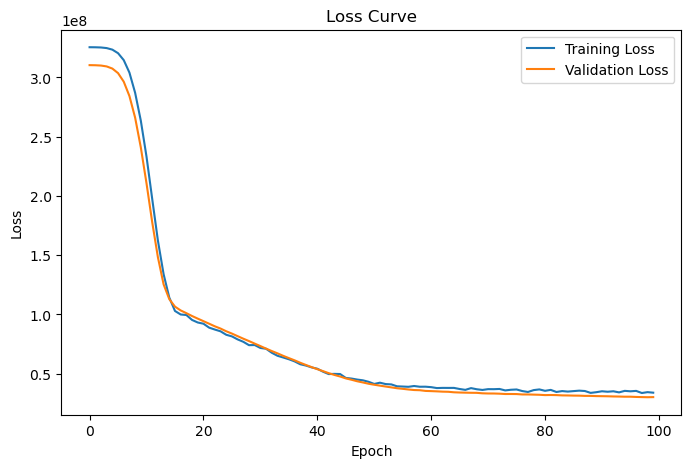

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

## MAE Curve:

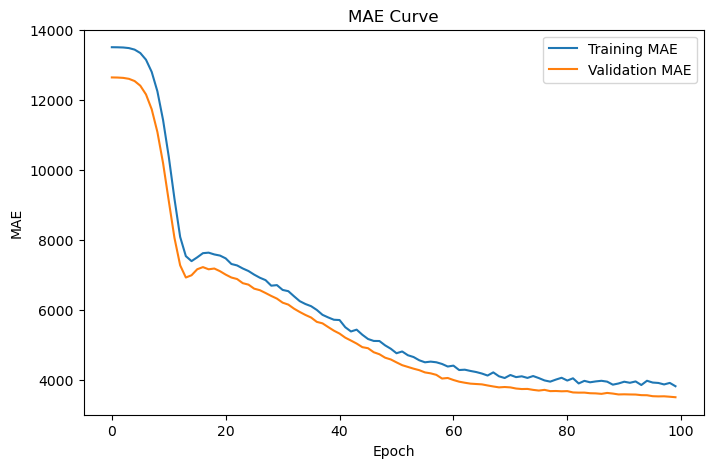

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"])
plt.plot(history.history["val_mae"])

plt.title("MAE Curve")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend([
    "Training MAE",
    "Validation MAE"
])

plt.show()

# Predictions:

In [16]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


# Evaluate Model:

In [17]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3682.6407952184
MSE : 29051315.48617645
RMSE: 5389.927224571446
R2 Score: 0.8128724453525351


# Actual vs Predicted Visualization:

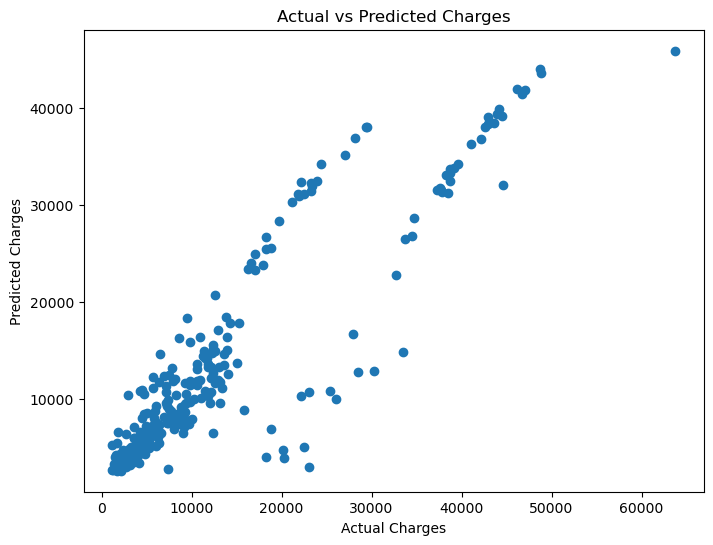

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title(
    "Actual vs Predicted Charges"
)

plt.show()

Interpretation

A good model produces points close to an imaginary diagonal line.

The closer the points are to that line:

- Lower Error
- Higher R²
- Better Predictions

# Save Model:

In [19]:
model.save(
    "medical_insurance_ann.keras"
)

In [20]:
loaded_model = tf.keras.models.load_model(
    "medical_insurance_ann.keras"
)

print(
    "Model Loaded Successfully"
)

Model Loaded Successfully
